In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score, accuracy_score
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE


This parquet file contains both image and text feature vectors (img_ and txt_ columns)
along with sentiment labels for each social media post. Using these pre-extracted embeddings lets us train models faster
without re-running the heavy CLIP feature extraction step.

In [21]:
# Load the CLIP embeddings from parquet file
df = pd.read_parquet('/Users/pgutti/CLIP/msa_vitl14_img+txt-embeddings.parquet')
display(df.head())


,id,text,label,img_0,img_1,img_2,img_3,img_4,img_5,img_6,...,txt_758,txt_759,txt_760,txt_761,txt_762,txt_763,txt_764,txt_765,txt_766,txt_767
0,2499,Knocked doors with the venerable #TeamTrudeau ...,positive,-0.033020,0.023422,-0.010773,-0.028641,-0.026077,0.018387,-0.053192,...,0.034363,0.039856,0.032806,-0.056732,-0.042114,0.062042,-0.017685,-0.011337,-0.004963,0.001048
1,2500,Canvassing for @ElectKellyYEG #yegfed #elxn42,neutral,-0.021774,-0.004269,-0.005325,0.036072,0.026108,-0.014374,-0.023438,...,0.000944,-0.003693,0.038330,-0.057770,-0.026123,0.035553,-0.005680,0.019272,-0.008705,0.020905
2,2501,An NPD gov't would institutionalize mediocrity...,negative,0.016510,-0.040894,-0.015625,-0.002232,-0.001537,0.052429,-0.027985,...,0.019058,0.014595,0.025467,-0.056946,-0.037140,-0.004982,0.018204,0.000758,-0.007927,0.009941
3,2502,"""""I think it's time for change"""" - Ana Commit ...",positive,0.017227,0.000619,0.015213,0.037048,0.004005,0.029144,-0.021835,...,-0.014282,0.006245,-0.000143,-0.039764,-0.007332,0.015030,0.017471,0.003677,-0.008965,0.004440
4,2503,The Past and Future of the Refugee Crisis - Th...,positive,-0.023651,0.023041,-0.069458,0.052856,0.006775,0.012054,-0.010330,...,-0.006145,-0.039246,0.019104,-0.042572,-0.003799,0.013855,-0.014824,0.005630,-0.019653,0.006107


Image embedding shape: (19596, 768)
Text embedding shape: (19596, 768)


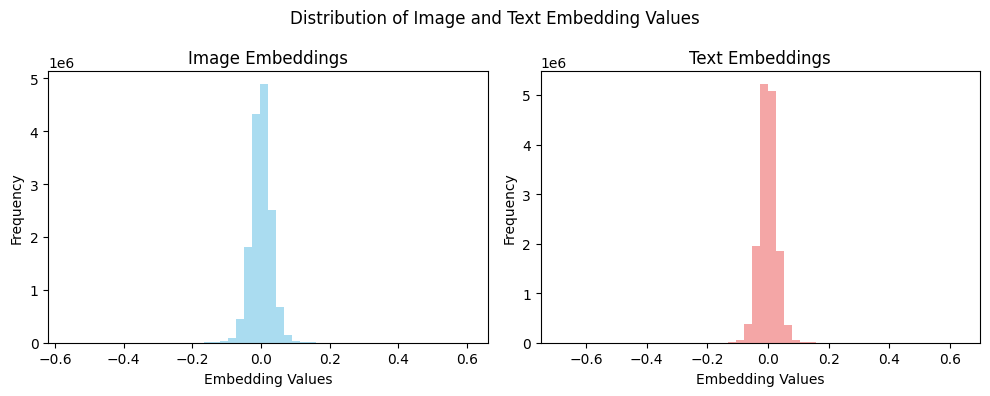

Label counts: Counter({'positive': 10460, 'neutral': 7742, 'negative': 1394})


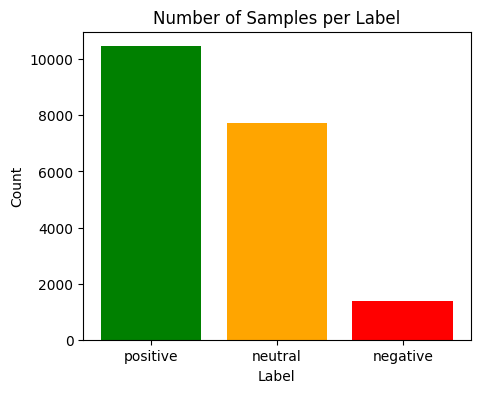

In [ ]:

img_cols = [c for c in df.columns if c.startswith("img_")]
txt_cols = [c for c in df.columns if c.startswith("txt_")]

print("Image embedding shape:", df[img_cols].shape)
print("Text embedding shape:", df[txt_cols].shape)

plt.figure(figsize=(10, 4))

# Plot histogram for image embeddings
plt.subplot(1, 2, 1)
plt.hist(df[img_cols].values.flatten(), bins=50, alpha=0.7, color='skyblue')
plt.title("Image Embeddings")
plt.xlabel("Embedding Values")
plt.ylabel("Frequency")

# Plot histogram for text embeddings
plt.subplot(1, 2, 2) 
plt.hist(df[txt_cols].values.flatten(), bins=50, alpha=0.7, color='lightcoral')
plt.title("Text Embeddings")
plt.xlabel("Embedding Values")
plt.ylabel("Frequency")

plt.suptitle("Distribution of Image and Text Embedding Values")
plt.tight_layout()
plt.show()

# how many samples belong to each sentiment label
labels = df['label'].to_numpy()
label_counts = Counter(labels)
print("Label counts:", label_counts)

# chart for label distribution
plt.figure(figsize=(5, 4))
plt.bar(label_counts.keys(), label_counts.values(), color=['green', 'orange', 'red'])
plt.title("Number of Samples per Label")
plt.xlabel("Label")
plt.ylabel("Count")
plt.show()



The next step:
1. Combines both image and text embeddings into a single feature matrix (X).
 - Each sample now contains information from both its image and text components.
2. Extract sentiment labels (y) corresponding to each sample.
3. Uses LabelEncoder to convert text labels (e.g., 'positive', 'neutral', 'negative') into numeric form so they can be used by machine learning models.
4. Stores the class names to easily interpret predictions later.

In [23]:
# Prepare features and labels
X = np.concatenate([df[img_cols].to_numpy(), df[txt_cols].to_numpy()], axis=1)
y = labels
le = LabelEncoder()
y_enc = le.fit_transform(y)
class_names = le.classes_


Use an 80/20 split — 80% of the data for training and 20% for testing.

In [24]:
# Split into train/test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc, test_size=0.2, stratify=y_enc, random_state=42)
print("Train size:", X_train.shape, "Test size:", X_test.shape)


Train size: (15676, 1536) Test size: (3920, 1536)


Used Smote and PCA for balancing and dimensionality reduction

In [25]:
smote = SMOTE(random_state=42)
pca = PCA(n_components=200, random_state=42)


In [26]:
# Set up classifiers in pipelines
log_pipe = ImbPipeline([
    ('smote', smote),
    ('scaler', StandardScaler()),
    ('pca', pca),
    ('clf', LogisticRegression(max_iter=2000, solver='lbfgs', class_weight='balanced', n_jobs=1))
])
#NN
mlp_pipe = ImbPipeline([
    ('smote', smote),
    ('scaler', StandardScaler()),
    ('pca', pca),
    ('clf', MLPClassifier(hidden_layer_sizes=(512, 256), activation='relu', 
                         max_iter=150, early_stopping=True, validation_fraction=0.1, random_state=42))
])


In [27]:
# Tune logistic regression 
param_grid = {'clf__C': [0.1, 1.0, 10.0], 'pca__n_components': [100, 200, 300]}
grid = GridSearchCV(log_pipe, param_grid, cv=3, scoring='f1_macro', n_jobs=-1)
grid.fit(X_train, y_train)
print("Best Logistic Regression Params:", grid.best_params_)


Best Logistic Regression Params: {'clf__C': 0.1, 'pca__n_components': 200}


In [28]:
#Train all classifiers
log_pipe.set_params(**grid.best_params_)
log_pipe.fit(X_train, y_train)
mlp_pipe.fit(X_train, y_train)


Pipeline(steps=[('smote', SMOTE(random_state=42)), ('scaler', StandardScaler()),
                ('pca', PCA(n_components=200, random_state=42)),
                ('clf',
                 MLPClassifier(early_stopping=True,
                               hidden_layer_sizes=(512, 256), max_iter=150,
                               random_state=42))])

In [29]:
y_pred_log = log_pipe.predict(X_test)
y_pred_mlp = mlp_pipe.predict(X_test)



--- Logistic Regression Results ---
              precision    recall  f1-score   support

    negative       0.23      0.62      0.34       279
     neutral       0.52      0.46      0.49      1549
    positive       0.70      0.61      0.65      2092

    accuracy                           0.55      3920
   macro avg       0.49      0.56      0.49      3920
weighted avg       0.60      0.55      0.57      3920



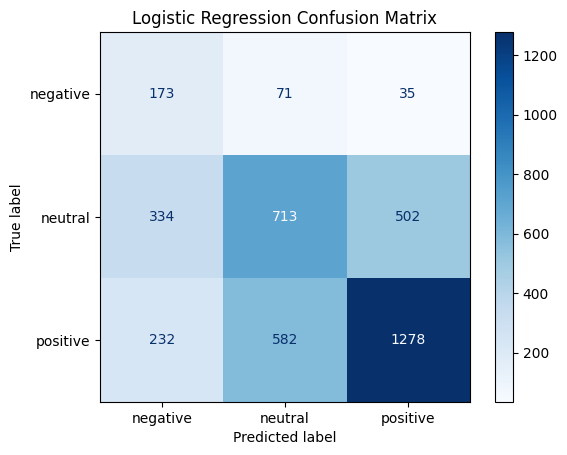


--- Neural Network Results ---
              precision    recall  f1-score   support

    negative       0.34      0.29      0.31       279
     neutral       0.51      0.44      0.47      1549
    positive       0.63      0.70      0.66      2092

    accuracy                           0.57      3920
   macro avg       0.49      0.48      0.48      3920
weighted avg       0.56      0.57      0.56      3920



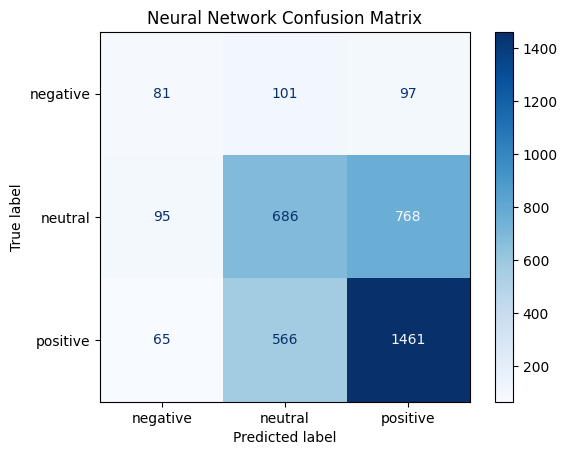

In [30]:
models = {
    "Logistic Regression": y_pred_log,
    "Neural Network": y_pred_mlp,
}

for name, preds in models.items():
    print(f"\n--- {name} Results ---")
    print(classification_report(y_test, preds, target_names=class_names))
    ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test, preds), display_labels=class_names).plot(cmap='Blues')
    plt.title(f"{name} Confusion Matrix")
    plt.show()


In [32]:
# summary of all main models

print("\n Summary")
for name, preds in models.items():
    print(f"{name} Accuracy: {accuracy_score(y_test, preds):.4f}")
    print(f"{name} F1: {f1_score(y_test, preds, average='macro'):.4f}")



 Summary
Logistic Regression Accuracy: 0.5520
Logistic Regression F1: 0.4944
Neural Network Accuracy: 0.5684
Neural Network F1: 0.4819


Overall, the models we’ve trained so far perform in the 45–60% accuracy range. Moving forward, we plan to focus on fine-tuning the models to improve both their accuracy and consistency. A key objective is to make the CLIP model more sensitive to sentiment distinctions—for example, detecting subtle emotional tones rather than relying solely on broad text-image similarity. We also aim to enhance the embedding representations to better capture nuanced relationships between visual and textual features. In addition, we plan to train deeper neural networks and experiment with different architectures, hyperparameters, and data augmentation techniques to identify the most effective model for sentiment analysis. Finally, we will train a transformer-based model and compare its performance against our manually developed approach to evaluate which method yields better results.

We will also compare how different image types impact sentiment prediction accuracy. 